## Data Visualization: Final Project
-  Dataset Selection: Choose one real-world dataset from a reliable source, such as: Kaggle, UCI Machine Learning Repository, Data.gov, etc.

- Dataset Understanding: Purpose of the dataset, number of records and features, data types, missing values, outliers.

- Visualization by Data Categories: Use multiple plots, each serving a specific analytical purpose.

#### Dataset:
https://www.kaggle.com/datasets/thedevastator/global-video-game-sales


Overview: The given dataset contains records of 15,000+ video games, each of which includes relevant information such as the game name, the platform, the release year, the sales of the game across multiple regions, and more.

In [ ]:
# Upload the file using google colab
from google.colab import files
uploaded = files.upload()

Saving vgsales.csv to vgsales.csv


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('vgsales.csv')

In [ ]:
# Set Rank as index
df = df.set_index('Rank')
df

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,,,,,,,,,,
1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...
16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01


### Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16598 entries, 1 to 16600
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          16598 non-null  object 
 1   Platform      16598 non-null  object 
 2   Year          16327 non-null  float64
 3   Genre         16598 non-null  object 
 4   Publisher     16540 non-null  object 
 5   NA_Sales      16598 non-null  float64
 6   EU_Sales      16598 non-null  float64
 7   JP_Sales      16598 non-null  float64
 8   Other_Sales   16598 non-null  float64
 9   Global_Sales  16598 non-null  float64
dtypes: float64(6), object(4)
memory usage: 1.4+ MB


In [ ]:
# Count of missing values
print(df.isnull().sum())

Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


### Imputation of Missing Values

In [ ]:
# Impute missing Publisher values with mode
df['Publisher'] = df['Publisher'].fillna(df['Publisher'].mode()[0])
# Impute missing Year values using mode per Platform
df['Year'] = df.groupby('Platform')['Year'].transform(lambda x:
                                                  x.fillna(x.mode()[0]))

# Revert the integer for year
df['Year'] = df['Year'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16598 entries, 1 to 16600
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          16598 non-null  object 
 1   Platform      16598 non-null  object 
 2   Year          16598 non-null  int64  
 3   Genre         16598 non-null  object 
 4   Publisher     16598 non-null  object 
 5   NA_Sales      16598 non-null  float64
 6   EU_Sales      16598 non-null  float64
 7   JP_Sales      16598 non-null  float64
 8   Other_Sales   16598 non-null  float64
 9   Global_Sales  16598 non-null  float64
dtypes: float64(5), int64(1), object(4)
memory usage: 1.4+ MB


### Data Analysis & Visualization

1. How many games were published by each of the game publishers?
- Plot the top 10 using a bar chart

In [ ]:
publisher_counts = df['Publisher'].value_counts()
print("Number of publishers:", len(publisher_counts))
publisher_counts.head(10) # Print the first 10

Number of publishers: 578


,count
Publisher,
Electronic Arts,1409
Activision,975
Namco Bandai Games,932
Ubisoft,921
Konami Digital Entertainment,832
THQ,715
Nintendo,703
Sony Computer Entertainment,683
Sega,639


<Axes: ylabel='Publisher'>

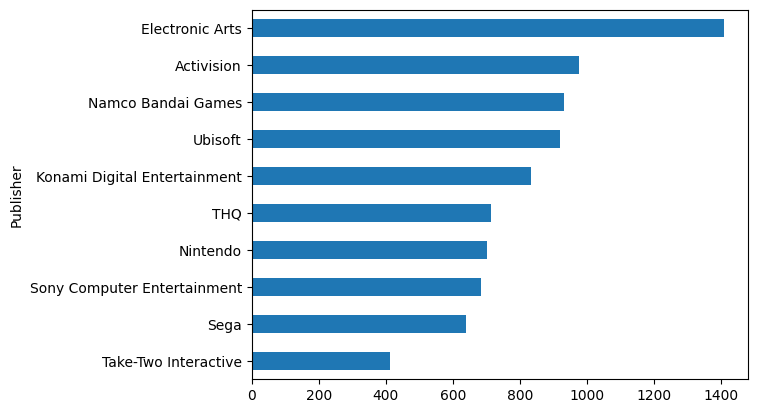

In [ ]:
publisher_counts.nlargest(10).sort_values().plot(kind='barh')

2. We want the total sales performance of each publisher, both globally, and individual regions?
- Plot the top 10 using a bar chart and a stacked bar chart

In [ ]:
# Group by and aggregate by sum of each sales
publisher_sales = df.groupby('Publisher')[['Global_Sales', 'NA_Sales',
                                          'EU_Sales', 'JP_Sales',
                                          'Other_Sales']].sum()
# Sort by Global Sales
publisher_sales = publisher_sales.sort_values(by='Global_Sales',
                                              ascending=False)
publisher_sales.head(10)

,Global_Sales,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Publisher,,,,,
Nintendo,1786.56,816.87,418.74,455.42,95.33
Electronic Arts,1125.20,603.61,375.95,14.97,130.44
Activision,727.46,429.70,215.53,6.54,75.34
Sony Computer Entertainment,607.50,265.22,187.72,74.10,80.45
Ubisoft,474.72,253.43,163.32,7.50,50.26
Take-Two Interactive,399.54,220.49,118.14,5.83,55.24
THQ,340.77,208.77,94.73,5.01,32.14
Konami Digital Entertainment,283.64,92.16,69.69,91.30,30.31
Sega,272.99,109.40,82.00,57.03,24.52


<Axes: xlabel='Publisher'>

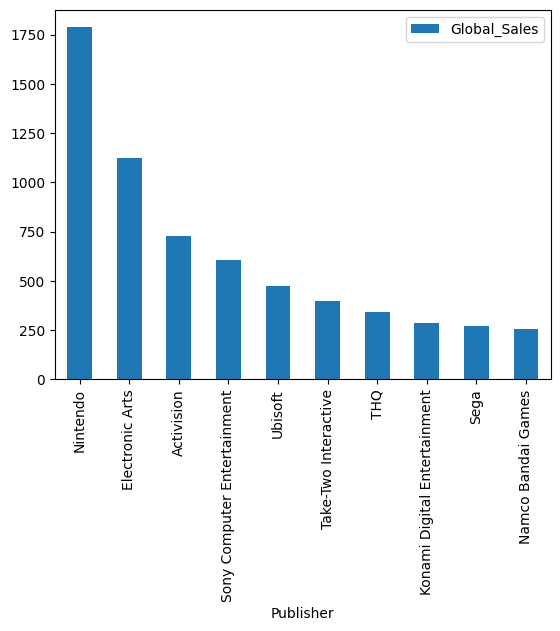

In [ ]:
# Plot a bar chart for only global sales
publisher_sales.head(10)['Global_Sales'].plot(kind='bar', legend=True)

<Axes: xlabel='Publisher'>

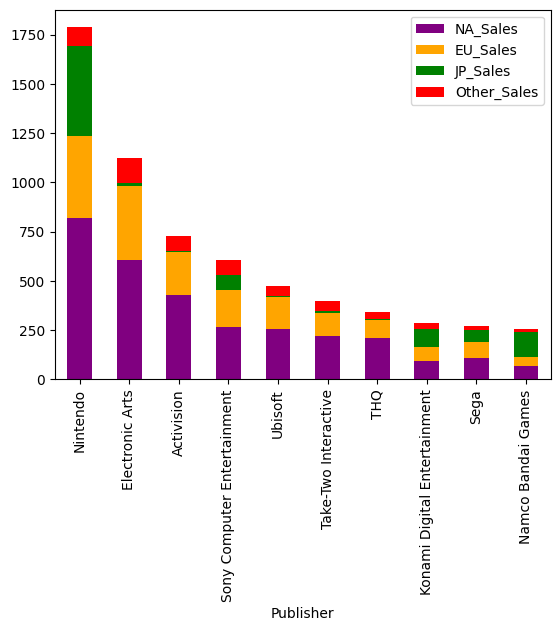

In [ ]:
# Plot a stacked bar chart for all regional sales
region_sales = ['NA_Sales','EU_Sales', 'JP_Sales', 'Other_Sales']
color = ['purple', 'orange', 'green', 'red']
publisher_sales.head(10)[region_sales].plot(kind='bar',
                                            stacked=True, color=color)

3. We want the total sales of all the games based on their released years?
- Based on global sales, during which game release year did the combined sales of all released titles reach their highest level?
- The purpose is to identify the release period in which games achieved their highest overall success in terms of total global sales.

In [ ]:
# Group sales data by Year
yearly_sales = df.groupby('Year')[[
    'Global_Sales', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'
]].sum()
# Get the top 5 year based on global sales
yearly_sales.nlargest(5, 'Global_Sales')

,Global_Sales,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Year,,,,,
2009,684.20,349.19,195.62,62.96,76.18
2008,682.43,353.59,184.98,60.81,82.63
2007,611.13,312.05,160.50,60.29,77.60
2010,600.45,304.24,176.73,59.49,59.90
2011,539.78,253.16,175.51,54.00,56.99


<Axes: xlabel='Year'>

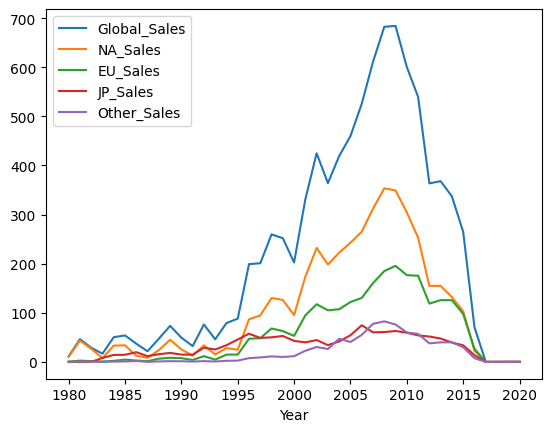

In [ ]:
# Line chart
# Which release year produced the most successful games overall?
yearly_sales.plot(kind='line')

4. We want to know in each released year, which game has the most sales?

The goal is not to determine the most popular game during a specific calendar year. Instead, we identify the game released in that year that eventually accumulated the highest total global sales over its entire lifetime, regardless of when those sales occurred.

In [ ]:
# Best selling game in every year based on global sales
best_selling_game_per_year = df.loc[df.groupby('Year')['Global_Sales'].idxmax()]
# Select only relevant columns (exclude regional sales)
best_selling_game_per_year = best_selling_game_per_year[
    ['Year', 'Name', 'Platform', 'Genre', 'Publisher', 'Global_Sales']
]
# Return every information + only global sales
best_selling_game_per_year.set_index('Year')

,Name,Platform,Genre,Publisher,Global_Sales
Year,,,,,
1980,Asteroids,2600,Shooter,Atari,4.31
1981,Pitfall!,2600,Platform,Activision,4.50
1982,Pac-Man,2600,Puzzle,Atari,7.81
1983,Baseball,NES,Sports,Nintendo,3.20
1984,Duck Hunt,NES,Shooter,Nintendo,28.31
1985,Super Mario Bros.,NES,Platform,Nintendo,40.24
1986,The Legend of Zelda,NES,Action,Nintendo,6.51
1987,Zelda II: The Adventure of Link,NES,Adventure,Nintendo,4.38
1988,Super Mario Bros. 3,NES,Platform,Nintendo,17.28


5. Next, we focus on the genre of game, we want to know which genre overall produce the best-selling games?

Do some genres dominate the market due to high volume, high sales per title, or both?

In [ ]:
# Group by Genre , aggregating by the number of games and the global sales
genre_stats = df.groupby('Genre').agg(Total_Global_Sales=('Global_Sales',
                                                          'sum'),
                                      Number_of_Games=('Name', 'count'))
# Sales Effiiency: This reveals genres that may release fewer
# but more successful titles.
genre_stats['Sales_Efficiency'] = (genre_stats['Total_Global_Sales']
                                         / genre_stats['Number_of_Games'])

genre_stats.sort_values(by='Sales_Efficiency', ascending=False)

,Total_Global_Sales,Number_of_Games,Sales_Efficiency
Genre,,,
Platform,831.37,886,0.938341
Shooter,1037.37,1310,0.791885
Role-Playing,927.37,1488,0.623233
Racing,732.04,1249,0.586101
Sports,1330.93,2346,0.567319
Fighting,448.91,848,0.529375
Action,1751.18,3316,0.528100
Misc,809.96,1739,0.465762
Simulation,392.20,867,0.452364


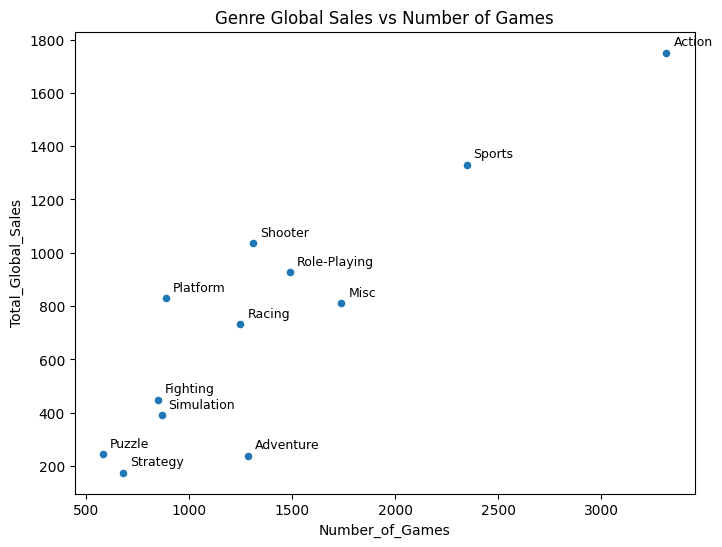

In [ ]:
import matplotlib.pyplot as plt

# 1. Create the scatter plot and capture the 'ax' (axes object)
ax = genre_stats.plot(kind='scatter',
                      x='Number_of_Games',
                      y='Total_Global_Sales',
                      figsize=(8, 6))

# 2. Iterate through rows to add labels
# Note: 'idx' is the Genre name because it is the index
for idx, row in genre_stats.iterrows():
    ax.annotate(idx, (row['Number_of_Games'], row['Total_Global_Sales']),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=9)

plt.title('Genre Global Sales vs Number of Games')
plt.show()

In [ ]:
import numpy as np
df.describe(include='all').replace({np.nan: 'No Info'})

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598,16598,16598.0,16598,16598,16598.0,16598.0,16598.0,16598.0,16598.0
unique,11493,31,No Info,12,578,No Info,No Info,No Info,No Info,No Info
top,Need for Speed: Most Wanted,DS,No Info,Action,Electronic Arts,No Info,No Info,No Info,No Info,No Info
freq,12,2163,No Info,3316,1409,No Info,No Info,No Info,No Info,No Info
mean,No Info,No Info,2006.386071,No Info,No Info,0.264667,0.146652,0.077782,0.048063,0.537441
std,No Info,No Info,5.859628,No Info,No Info,0.816683,0.505351,0.309291,0.188588,1.555028
min,No Info,No Info,1980.0,No Info,No Info,0.0,0.0,0.0,0.0,0.01
25%,No Info,No Info,2003.0,No Info,No Info,0.0,0.0,0.0,0.0,0.06
50%,No Info,No Info,2007.0,No Info,No Info,0.08,0.02,0.0,0.01,0.17
75%,No Info,No Info,2010.0,No Info,No Info,0.24,0.11,0.04,0.04,0.47


- To analyze the distribution of global sales among the highest-selling 100 games, we can use a histogram.
- Most of the top 100 games cluster at moderate sales levels, while a few blockbusters (e.g., Wii Sports, Mario titles) reach extremely high sales, creating a right-skewed distribution.

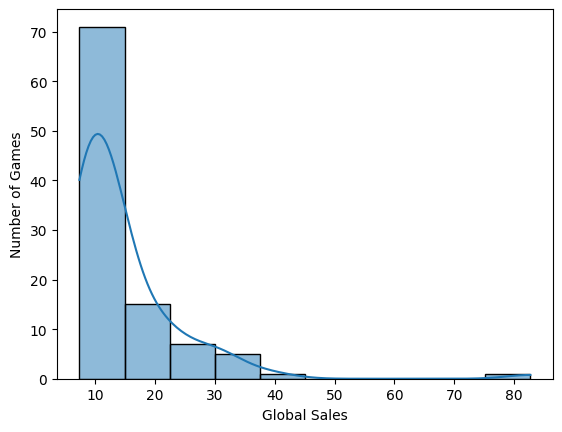

In [ ]:
# Plot a Histogram for distribution of
# global sales across the top 100 games
import seaborn as sns
import matplotlib.pyplot as plt

top_100_games = df.sort_values(by='Global_Sales', ascending=False).head(100)
sns.histplot(top_100_games['Global_Sales'], bins=10, kde=True)
plt.xlabel('Global Sales')
plt.ylabel('Number of Games')
plt.show()

To understand how top games perform across different regions, we can visualize the distribution of sales in North America, Europe, Japan, and Other regions using Kernel Density Estimation (KDE) plots. This provides insight into regional market preferences and highlights variations in sales patterns.
- North America and Europe show the highest sales density for top games, indicating strong market dominance.
- Japan has a smaller peak but is notable for certain blockbuster titles.
- Other regions contribute modestly, reflecting a smaller market share.
- The KDE plots highlight differences in regional preferences and confirm that even top-selling games do not perform uniformly across all markets.

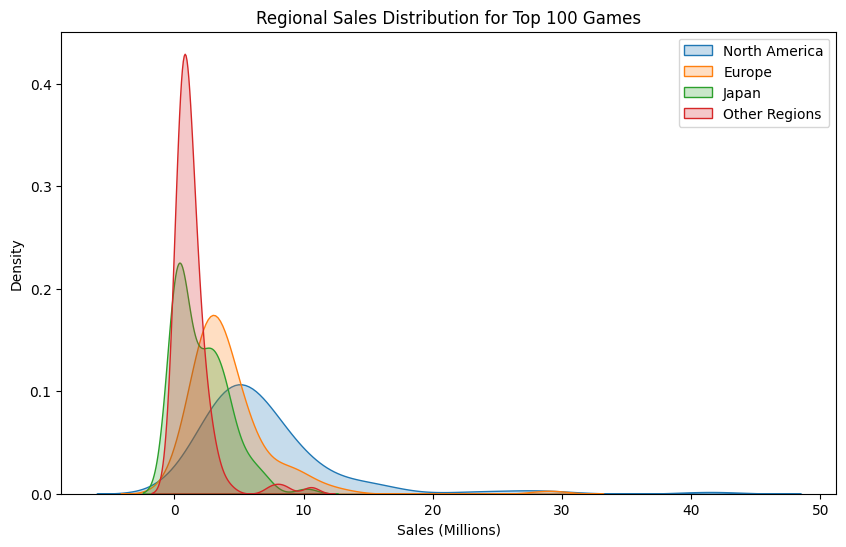

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Plot KDE for each regional sales
sns.kdeplot(top_100_games['NA_Sales'], label='North America', fill=True)
sns.kdeplot(top_100_games['EU_Sales'], label='Europe', fill=True)
sns.kdeplot(top_100_games['JP_Sales'], label='Japan', fill=True)
sns.kdeplot(top_100_games['Other_Sales'], label='Other Regions', fill=True)

plt.xlabel('Sales (Millions)')
plt.ylabel('Density')
plt.title('Regional Sales Distribution for Top 100 Games')
plt.legend()
plt.show()

After analyzing sales trends, genres, and publishers, we now examine how different gaming platforms contribute to global sales across time.
This analysis combines platform, time, and sales intensity, making it a multivariate and correlation-based visualization.

A heatmap is particularly suitable here because it highlights patterns, dominance periods, and transitions between platforms over time.

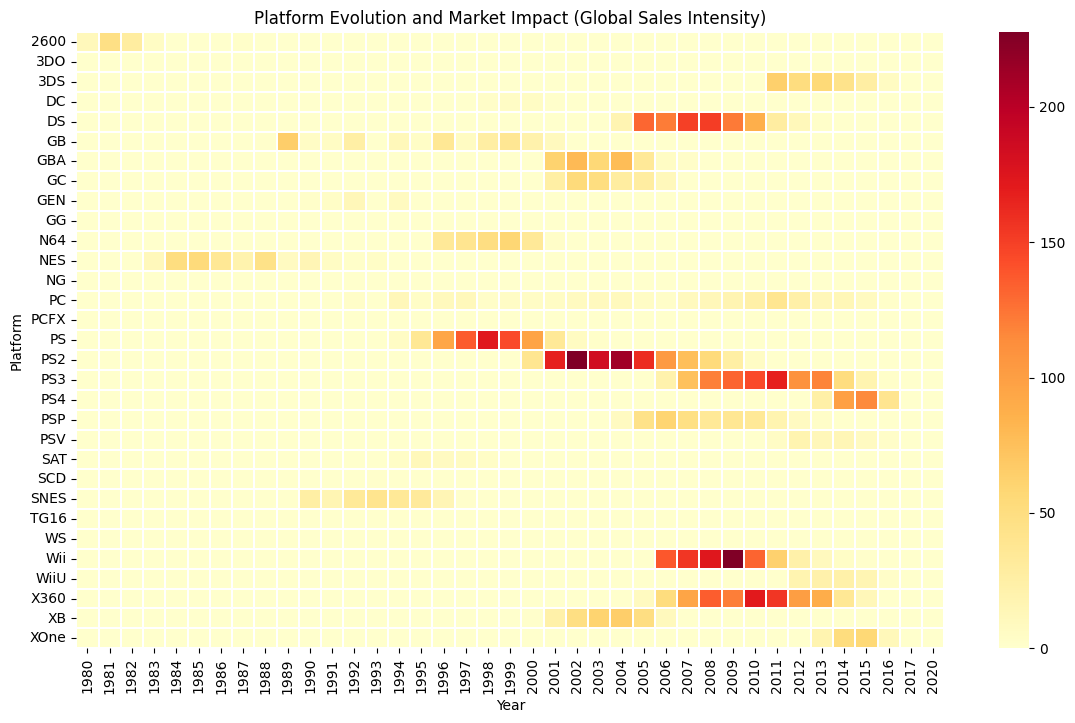

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregate global sales by Year and Platform
platform_year_sales = (
    df.groupby(['Year', 'Platform'])['Global_Sales']
      .sum()
      .unstack()
      .fillna(0)
)
plt.figure(figsize=(14,8))

sns.heatmap(
    platform_year_sales.T,
    cmap='YlOrRd',
    linewidths=0.1
)

plt.xlabel('Year')
plt.ylabel('Platform')
plt.title('Platform Evolution and Market Impact (Global Sales Intensity)')
plt.show()

In [ ]:
platform_year_sales

Platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
Year,,,,,,,,,,,,,,,,,,,,,
1980,11.38,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1981,46.28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1982,28.86,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1983,5.83,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1984,0.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1985,0.45,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1986,0.66,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1987,1.98,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1988,0.75,0.00,0.00,0.00,0.00,1.43,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [ ]:
# Identify top 10 platforms by total global sales
top_platforms = (
    df.groupby('Platform')['Global_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)

# Aggregate yearly global sales for top 10 platforms
platform_year_sales = (
    df[df['Platform'].isin(top_platforms)]
    .groupby(['Year', 'Platform'])['Global_Sales']
    .sum()
    .unstack()
    .fillna(0)
)

In [ ]:
platform_year_sales

Platform,DS,GBA,PC,PS,PS2,PS3,PS4,PSP,Wii,X360
Year,,,,,,,,,,
1985,0.02,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1988,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1992,0.00,0.00,3.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1994,0.00,0.00,12.85,6.02,0.00,0.00,0.00,0.00,0.00,0.00
1995,0.00,0.00,4.23,35.92,0.00,0.00,0.00,0.00,0.00,0.00
1996,0.00,0.00,10.59,94.68,0.00,0.00,0.00,0.00,0.00,0.00
1997,0.00,0.00,11.26,136.08,0.00,0.00,0.00,0.00,0.00,0.00
1998,0.00,0.00,3.28,172.85,0.00,0.00,0.00,0.00,0.00,0.00
1999,0.00,0.00,4.75,144.57,0.00,0.00,0.00,0.00,0.00,0.00


<Figure size 1400x700 with 0 Axes>

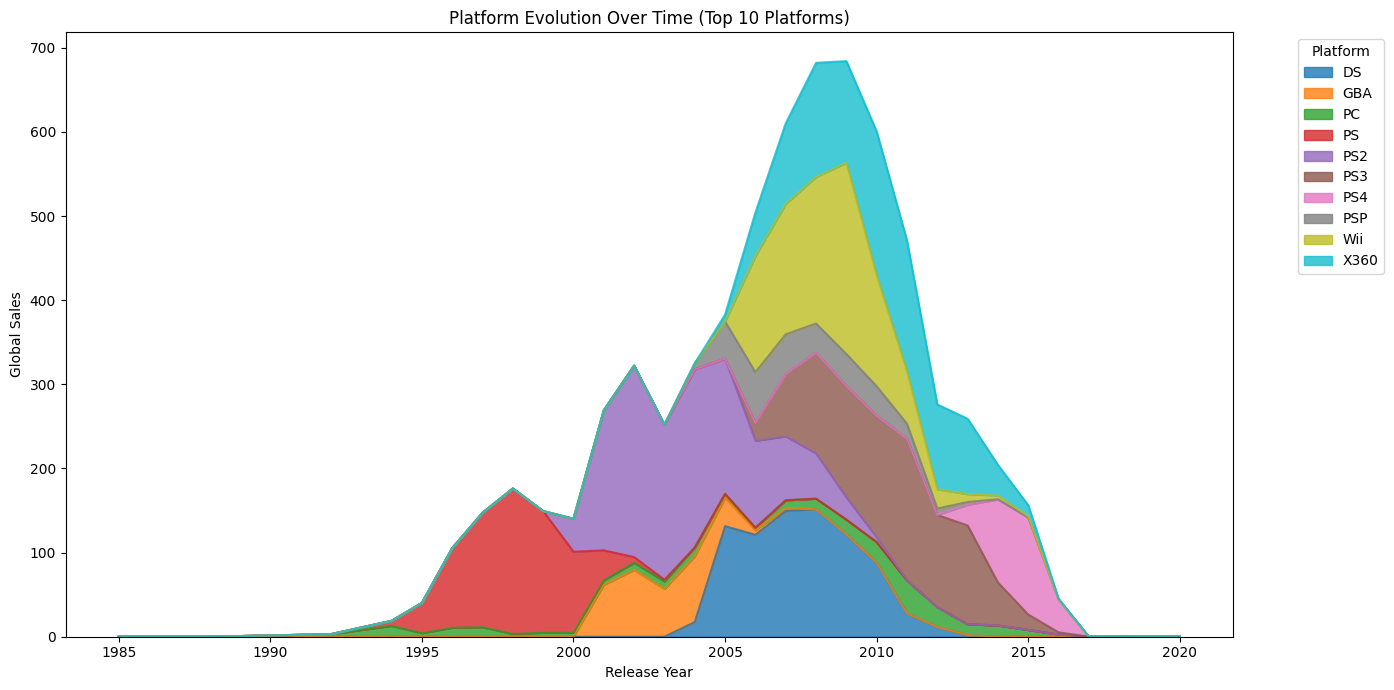

In [ ]:
plt.figure(figsize=(14,7))

platform_year_sales.plot(
    kind='area',
    stacked=True,
    figsize=(14,7),
    alpha=0.8
)

plt.xlabel('Release Year')
plt.ylabel('Global Sales')
plt.title('Platform Evolution Over Time (Top 10 Platforms)')
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Aggregate yearly global sales by platform
platform_year_sales_long = (
    df.groupby(['Platform', 'Year'])['Global_Sales']
      .sum()
      .reset_index()
)

# Keep only top 10 platforms for readability
top_platforms = (
    df.groupby('Platform')['Global_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)

platform_year_sales_long = platform_year_sales_long[
    platform_year_sales_long['Platform'].isin(top_platforms)
]

platform_year_sales_long

,Platform,Year,Global_Sales
25,DS,1985,0.02
26,DS,2004,17.46
27,DS,2005,131.40
28,DS,2006,121.15
29,DS,2007,149.36
...,...,...,...
223,X360,2012,100.88
224,X360,2013,89.61
225,X360,2014,36.42
226,X360,2015,13.05


In [ ]:
pc_platform = platform_year_sales_long[platform_year_sales_long['Platform'] == 'PC']
print(pc_platform['Global_Sales'].median(), pc_platform['Global_Sales'].max(),
      pc_platform['Global_Sales'].min())
pc_platform

8.78 39.02 0.03


,Platform,Year,Global_Sales
95,PC,1985,0.03
96,PC,1988,0.03
97,PC,1992,3.02
98,PC,1994,12.85
99,PC,1995,4.23
100,PC,1996,10.59
101,PC,1997,11.26
102,PC,1998,3.28
103,PC,1999,4.75
104,PC,2000,4.68


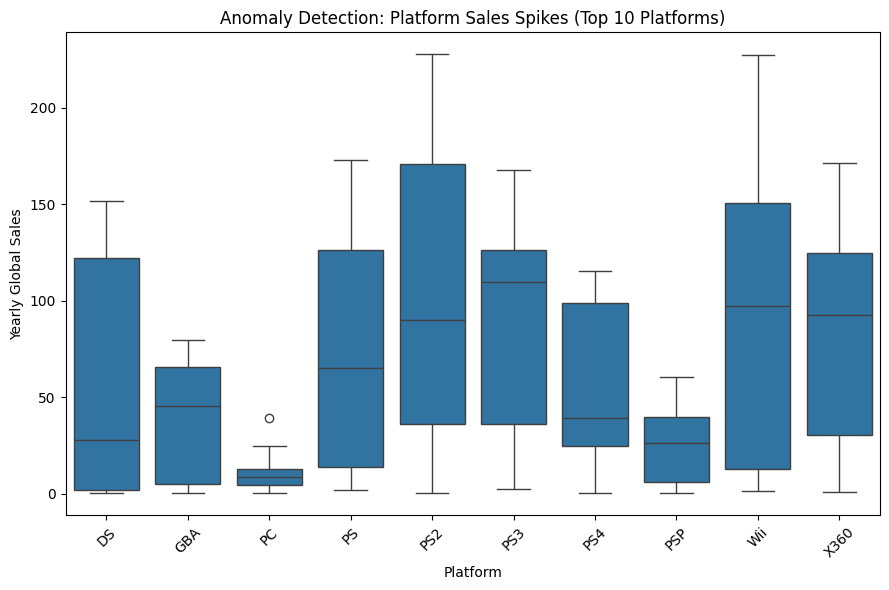

In [ ]:
plt.figure(figsize=(9,6))

sns.boxplot(
    data=platform_year_sales_long,
    x='Platform',
    y='Global_Sales'
)

plt.xlabel('Platform')
plt.ylabel('Yearly Global Sales')
plt.title('Anomaly Detection: Platform Sales Spikes (Top 10 Platforms)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A pie chart is ideal for showing part-to-whole relationships, helping visualize how much each game contributes to total global sales.

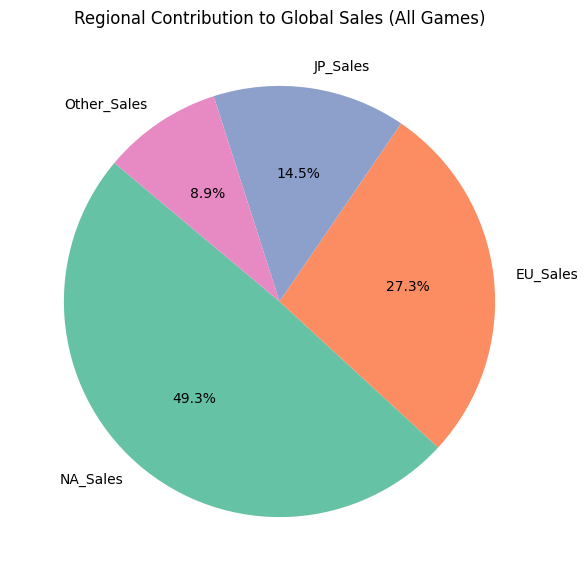

In [ ]:
# Aggregate total sales by region for all games
region_sales_all = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

plt.figure(figsize=(7,7))
plt.pie(
    region_sales_all,
    labels=region_sales_all.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66c2a5','#fc8d62','#8da0cb','#e78ac3']
)
plt.title('Regional Contribution to Global Sales (All Games)')
plt.show()

In [ ]:
region_sales_all

,0
NA_Sales,4392.95
EU_Sales,2434.13
JP_Sales,1291.02
Other_Sales,797.75


In [ ]:
import plotly.express as px
import pandas as pd

# Define countries per region
north_america = ['USA', 'CAN', 'MEX']
europe = [
    'FRA','DEU','GBR','ITA','ESP','NLD','BEL','CHE','AUT','SWE',
    'NOR','DNK','FIN','POL','PRT','IRL','CZE','HUN','GRC'
]
japan = ['JPN']

# Create expanded dataset
geo_data = pd.DataFrame({
    'ISO_Code': north_america + europe + japan,
    'Region': (
        ['North America'] * len(north_america) +
        ['Europe'] * len(europe) +
        ['Japan'] * len(japan)
    )
})

# Map total sales to regions
region_sales_map = {
    'North America': df['NA_Sales'].sum(),
    'Europe': df['EU_Sales'].sum(),
    'Japan': df['JP_Sales'].sum()
}

geo_data['Total_Sales'] = geo_data['Region'].map(region_sales_map)

# Plot choropleth
fig = px.choropleth(
    geo_data,
    locations='ISO_Code',
    color='Total_Sales',
    hover_name='Region',
    color_continuous_scale=px.colors.sequential.Plasma,
    title='Global Video Game Sales by Region'
)

fig.update_geos(showcoastlines=True, showland=True)
fig.update_layout(
    legend_title_text='Total Sales (Millions)',
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()

Sony wants to check whether total global sales of all PlayStation games
(PS2, PS3, PS4) have reached $5,000 million (10 billion units).

In [ ]:
import plotly.graph_objects as go

# Filter PlayStation platforms
ps_platforms = ['PS2', 'PS3', 'PS4']

ps_sales = df[df['Platform'].isin(ps_platforms)]['Global_Sales'].sum()
remaining_sales = max(target_sales - ps_sales, 0)
print("PlayStation Sales:", ps_sales)
print("Remaining Sales to reach 5000:", remaining_sales)

PlayStation Sales: 2491.5800000000004
Remaining Sales to reach 5000: 2508.4199999999996


In [ ]:
# Gauge Indicator: Progress Toward $5,000 Target
# Target sales
target_sales = 5000

fig = go.Figure(go.Indicator(
    mode="gauge+number+delta",
    value=ps_sales,
    number={'valueformat': '.2f'},
    delta={
        'reference': target_sales,
        'valueformat': '.2f'
    },
    gauge={
        'axis': {'range': [0, target_sales]},
        'bar': {'color': "royalblue"},
        'threshold': {
            'line': {'color': "red", 'width': 4},
            'thickness': 0.75,
            'value': target_sales},
        'steps': [
            {'range': [0, target_sales * 0.6], 'color': "lightgray"},
            {'range': [target_sales * 0.6, target_sales * 0.85], 'color': "gray"},
            {'range': [target_sales * 0.85, target_sales], 'color': "lightgreen"}]
    },
    title={'text': "PlayStation Sales Progress Toward $5,000 Target"}
))

fig.show()

In [ ]:
# Reset index to keep original Rank as a column
df_reset = df.reset_index()

# Aggregate sales by game name (franchise proxy) for PlayStation platforms
ps_franchise_sales = (
    df_reset[df_reset['Platform'].isin(ps_platforms)]
    .groupby('Name', as_index=False)
    .agg(
        Total_Global_Sales=('Global_Sales', 'sum'),
        Best_Rank=('Rank', 'min')  # Best (highest) original rank
    )
    .sort_values(by='Total_Global_Sales', ascending=False)
)

# Add new ranking based on PlayStation total sales
ps_franchise_sales['PS_Sales_Rank'] = range(1, len(ps_franchise_sales) + 1)

# Show top 10 games
ps_franchise_sales.head(10).set_index('PS_Sales_Rank')

,Name,Total_Global_Sales,Best_Rank
PS_Sales_Rank,,,
1,Grand Theft Auto V,33.38,17
2,Grand Theft Auto: San Andreas,20.81,18
3,Grand Theft Auto: Vice City,16.15,25
4,Call of Duty: Black Ops 3,16.03,34
5,Gran Turismo 3: A-Spec,14.98,29
6,Call of Duty: Black Ops II,14.03,35
7,Call of Duty: Modern Warfare 3,13.46,38
8,Call of Duty: Ghosts,13.22,68
9,Grand Theft Auto III,13.10,39
